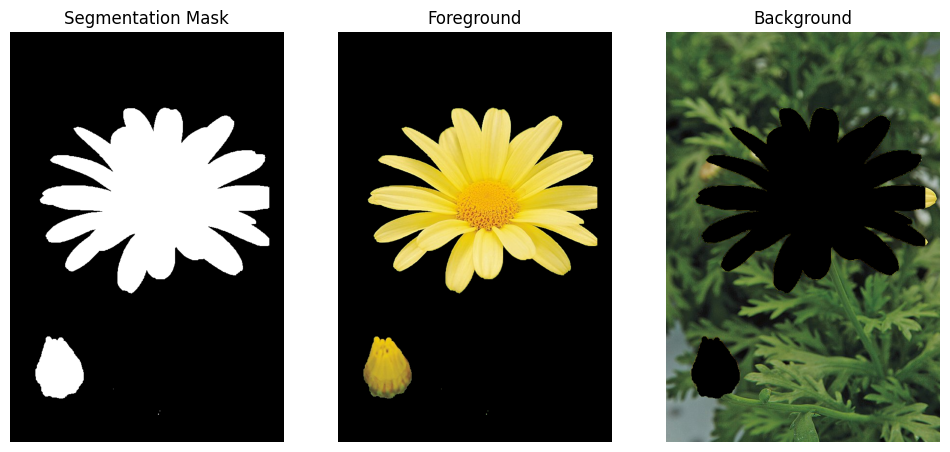

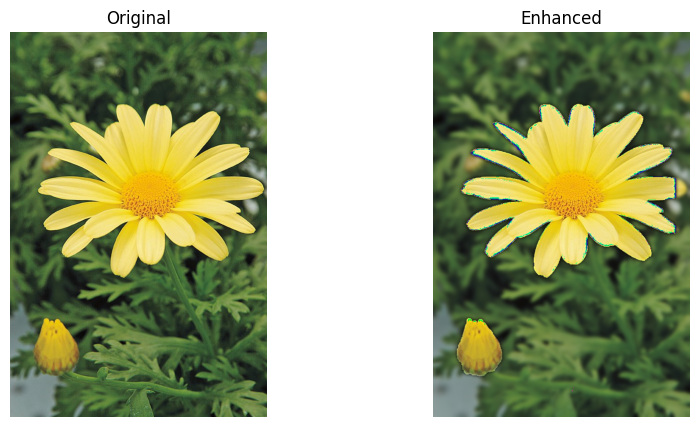

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/sample_data/daisy.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


mask = np.zeros(img.shape[:2], np.uint8)

bgdModel = np.zeros((1,65), np.float64)
fgdModel = np.zeros((1,65), np.float64)

rect = (30, 30, img.shape[1]-60, img.shape[0]-60)

cv2.grabCut(img_rgb, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

mask2 = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')

foreground = img_rgb * mask2[:, :, np.newaxis]
background = img_rgb * (1 - mask2[:, :, np.newaxis])

plt.figure(figsize=(12,6))
plt.subplot(1,3,1); plt.title("Segmentation Mask"); plt.imshow(mask2, cmap='gray'); plt.axis('off')
plt.subplot(1,3,2); plt.title("Foreground"); plt.imshow(foreground); plt.axis('off')
plt.subplot(1,3,3); plt.title("Background"); plt.imshow(background); plt.axis('off')
plt.show()


blurred_background = cv2.GaussianBlur(background, (21,21), 0)

enhanced_img = foreground + blurred_background


plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(img_rgb); plt.axis('off')
plt.subplot(1,2,2); plt.title("Enhanced"); plt.imshow(enhanced_img); plt.axis('off')
plt.show()
